In [44]:
%load_ext rich
%load_ext autoreload
%autoreload 2

The rich extension is already loaded. To reload it, use:
  %reload_ext rich
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
import logging
import os
from functools import partial

import astropy.units as u
import matplotlib.pyplot as plt  # type: ignore
import numpy as np
from joblib import Parallel, delayed
from pixell import curvedsky
from tqdm.auto import tqdm

from ksw_joblib import KSW_joblib
from scripts import core  # note the small c to import the core module and not the class

from scripts import Core
from scripts.utils import remove_mono_dipole, setup_logging
from scripts.utils.plots import plot_cl_alm, plot_patches

# Monkey patch the core module
core.KSW = KSW_joblib

logger = setup_logging(__name__, level=logging.DEBUG, use_rich=True)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("healpy").setLevel(logging.WARNING)

## Setup

In [46]:
s = Core(
    [
        "settings/planck.json",
        "--nsims",
        "1",
        "--narray",
        "1",
        "--beam_width",
        "0",
        # "--noise_scale_tt",
        # "10",
    ]
)
s.is_main_job = True  # fix an issue with missing slurm job array

23-Apr-24 11:56:44 - scripts.core - DEBUG - Parsing CLI args: ['settings/planck.json', '--nsims', '1',  ]8;id=318113;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=981348;file:///users/stevensonb/Research/MLPNG/scripts/core.py#121\121]8;;\
'--narray', '1', '--beam_width', '0']                                                                              

23-Apr-24 11:56:44 - scripts.core - INFO - Loading settings from file settings/planck.json              ]8;id=134710;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=372542;file:///users/stevensonb/Research/MLPNG/scripts/core.py#139\139]8;;\

23-Apr-24 11:56:44 - scripts.core - DEBUG - Forcing setting 'nsims' to '1' due to CLI                   ]8;id=220803;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=220865;file:///users/stevensonb/Research/MLPNG/scripts/core.py#146\146]8;;\

23-Apr-24 11:56:44 - scripts.core - DEBUG - Forcing setting 'narray' to '1' due to CLI                  ]8;id=750686;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=971794;file:///users/stevensonb/Research/MLPNG/scripts/core.py#146\146]8;;\

23-Apr-24 11:56:44 - scripts.core - DEBUG - Forcing setting 'beam_width' to '0.0' due to CLI            ]8;id=909632;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=162047;file:///users/stevensonb/Research/MLPNG/scripts/core.py#146\146]8;;\

...

23-Apr-24 11:57:17 - scripts.core - DEBUG - Setting 'plot_dir' not found, using default: 'plots'        ]8;id=108486;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=388655;file:///users/stevensonb/Research/MLPNG/scripts/core.py#249\249]8;;\

23-Apr-24 11:57:17 - scripts.core - DEBUG - Setting 'tb_dir' not found, using default: 'tensorboard'    ]8;id=518067;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=644295;file:///users/stevensonb/Research/MLPNG/scripts/core.py#249\249]8;;\

23-Apr-24 11:57:17 - scripts.core - DEBUG - Setting 'model_dir' not found, using default: 'models'      ]8;id=211416;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=243058;file:///users/stevensonb/Research/MLPNG/scripts/core.py#249\249]8;;\

23-Apr-24 11:57:17 - scripts.core - DEBUG - Setting 'alm_dir' not found, using default: 'alms'          ]8;id=271194;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=884776;file:///users/stevensonb/Research/MLPNG/scripts/core.py#249\249]8;;\

23-Apr-24 11:57:17 - scripts.core - DEBUG - Setting 'patch_dir' not found, using default: 'patches'     ]8;id=354653;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=981235;file:///users/stevensonb/Research/MLPNG/scripts/core.py#249\249]8;;\

## Alm

In [47]:
from scripts.almgen import generate_alm_ng

This code generates the alms

$$a_{\ell m} = a_{\ell m}^{{G}} + f_{NL}^X a_{\ell m}^{NG}$$
with
$$a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]$$
and
$$\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)$$
$$\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)$$
$$B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}$$
where $\Delta_\phi$ is primordial normalization, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions   

23-Apr-24 11:57:18 - scripts.utils.plots - INFO - camb_cl: (1023,), beam: (1023,), noise: (1025,)       ]8;id=683186;file:///users/stevensonb/Research/MLPNG/scripts/utils/plots.py\plots.py]8;;\:]8;id=299362;file:///users/stevensonb/Research/MLPNG/scripts/utils/plots.py#76\76]8;;\

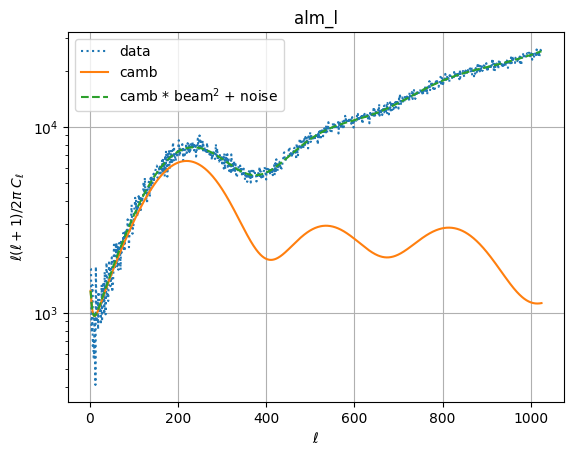

23-Apr-24 11:57:43 - scripts.almgen - INFO - Starting non-gaussian Alm generation                      ]8;id=672037;file:///users/stevensonb/Research/MLPNG/scripts/almgen.py\almgen.py]8;;\:]8;id=2786;file:///users/stevensonb/Research/MLPNG/scripts/almgen.py#69\69]8;;\

23-Apr-24 11:57:43 - scripts.almgen - DEBUG - Using temp folder for almng generation:                  ]8;id=861121;file:///users/stevensonb/Research/MLPNG/scripts/almgen.py\almgen.py]8;;\:]8;id=295247;file:///users/stevensonb/Research/MLPNG/scripts/almgen.py#70\70]8;;\
/lustre/scratch/client/users/stevensonb                                                                            

Alm_ng:   0%|          | 0/1 [00:00<?, ?it/s]

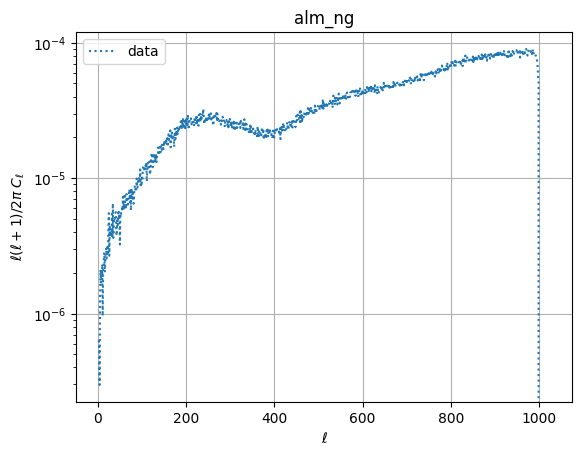

23-Apr-24 11:58:15 - scripts.utils.plots - INFO - camb_cl: (1023,), beam: (1023,), noise: (1025,)       ]8;id=528427;file:///users/stevensonb/Research/MLPNG/scripts/utils/plots.py\plots.py]8;;\:]8;id=614867;file:///users/stevensonb/Research/MLPNG/scripts/utils/plots.py#76\76]8;;\

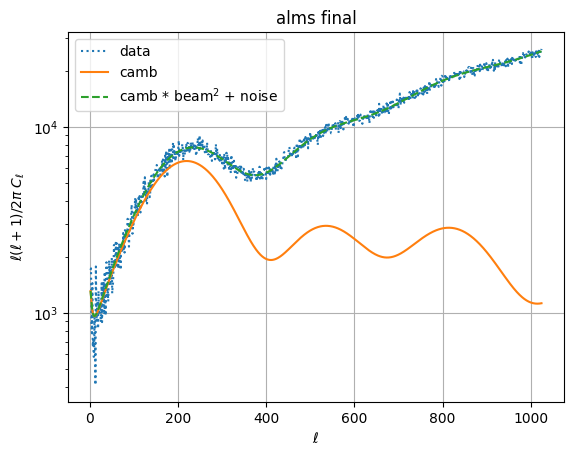

In [48]:
alm_l = np.array(
    [s.data.compute_alm_sim(s.lensing) for _ in range(s.nsims)],
    dtype=s.c_dtype,
)
plot_cl_alm(
    alm_l[0, 0],
    title="alm_l",
    plot_camb=True,
    c_ells=s.c_ells,
    camb_noise=True,
    noise=s.noise_ell[0],
    beam_width=s.beam_width,
)
fnls = s.rng.uniform(s.fnl_min, s.fnl_max, s.fnl_shape)
alm_ng = generate_alm_ng(s, alm_l)
plot_cl_alm(alm_ng[0, 0], title="alm_ng")
alms = alm_l + fnls * alm_ng
alms = remove_mono_dipole(alms)
plot_cl_alm(
    alms[0, 0],
    title="alms final",
    plot_camb=True,
    c_ells=s.c_ells,
    camb_noise=True,
    noise=s.noise_ell[0],
    beam_width=s.beam_width,
)

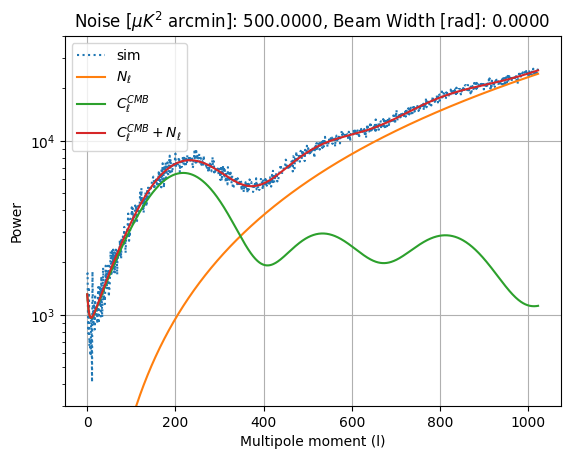

In [49]:
ells = np.arange(2, s.nell)
scale = ells * (ells + 1) / 2 / np.pi
N_ell = s.noise_ell[0, 2:]
cl_cmb = s.c_ells[2 : s.nell, 0]
cl_sim = curvedsky.alm2cl(alms[0, 0])[2 : s.nell]
beam = s.beam_ell[0, 2:]

plot_func = plt.semilogy
plot_func(scale * cl_sim, label=r"sim", linestyle=":")
plot_func(scale * N_ell, label=r"$N_\ell$")
plot_func(scale * cl_cmb, label=r"$C_{\ell}^{CMB}$")
plot_func(scale * (cl_cmb * beam**2 + N_ell), label=r"$C_\ell^{CMB} + N_\ell$")
plt.legend()
plt.xlabel("Multipole moment (l)")
plt.ylabel("Power")
plt.grid(True)
plt.ylim([3e2, 4e4])
noise_muk2arcmin = (s.noise_scale_tt * u.radian).to_value(u.arcmin)
plt.title(
    f"Noise [$\\mu K^2$ arcmin]: {noise_muk2arcmin:.4f}, Beam Width [rad]: {s.beam_width:.4f}"
)
plt.show()

## PatchGen

In [50]:
from scripts.patchgen import cutSqPatches_lenspyx, cutSqPatches_pixell, get_fs_patch_geo

In [51]:
# Here we get the geometry of our patches in a tuple
patch_geo = get_fs_patch_geo(s)

# we also setup the cutPatches function to use either pixell or lenspyx
# depending on if we are doing lensing or not, and provide a lot of
# arguments that are needed and will stay constant
# we cannot abuse the python scope here since these will need to be pickled
common_settings = [
    s.lmax,
    s.plot_dir,
    s.base_name,
    s.npatches,
    s.c_ells,
    *patch_geo,
]
if s.lensing:
    max_l = s.cosmo_params["max_l"]
    cl_phi = s.cosmo._camb_data.get_lens_potential_cls(  # type: ignore
        max_l, CMB_unit="muK", raw_cl=True
    )[:, 0]

    cutPatches = partial(
        cutSqPatches_lenspyx, *common_settings, max_l, cl_phi, s.nside, s.r_dtype
    )
else:
    cutPatches = partial(cutSqPatches_pixell, *common_settings)

## Start the patch generation
# create the array to store the patches
patches = np.empty(s.patch_shape, dtype=s.r_dtype)

# We use joblib.parallel to generate the patches in parallel
# by default (temp_folder=None) this will use a ram disk /dev/shm
# if the data files are larger than the available memory, about 1TB, it will error
# so we give it a temp folder to use, which wont have that problem
temp_folder = os.environ.get("SCRATCH", None)
logger.debug(f"Using temp folder for patch generation: {temp_folder}")
patch_generator = Parallel(
    n_jobs=1,
    return_as="generator",
    temp_folder=temp_folder,
)(delayed(cutPatches)(alms[i, j], fnls[i, j], True) for i, j in s.sim_pol)

# Get our data from the generator, only update logging every 100 runs, takes a long time
logger.info(s.sim_pol_len)
for idx, result in enumerate(
    tqdm(patch_generator, desc="patch progress", total=s.sim_pol_len)
):
    i, pol = s.sim_pol[idx]
    patches[i, pol] = result

23-Apr-24 11:58:16 - __main__ - DEBUG - Using temp folder for patch generation:                    ]8;id=335338;file:///tmp/ipykernel_2679709/4184160827.py\4184160827.py]8;;\:]8;id=820065;file:///tmp/ipykernel_2679709/4184160827.py#37\37]8;;\
/lustre/scratch/client/users/stevensonb                                                                            

23-Apr-24 11:58:16 - __main__ - INFO - 1                                                           ]8;id=488723;file:///tmp/ipykernel_2679709/4184160827.py\4184160827.py]8;;\:]8;id=846215;file:///tmp/ipykernel_2679709/4184160827.py#45\45]8;;\

patch progress:   0%|          | 0/1 [00:00<?, ?it/s]

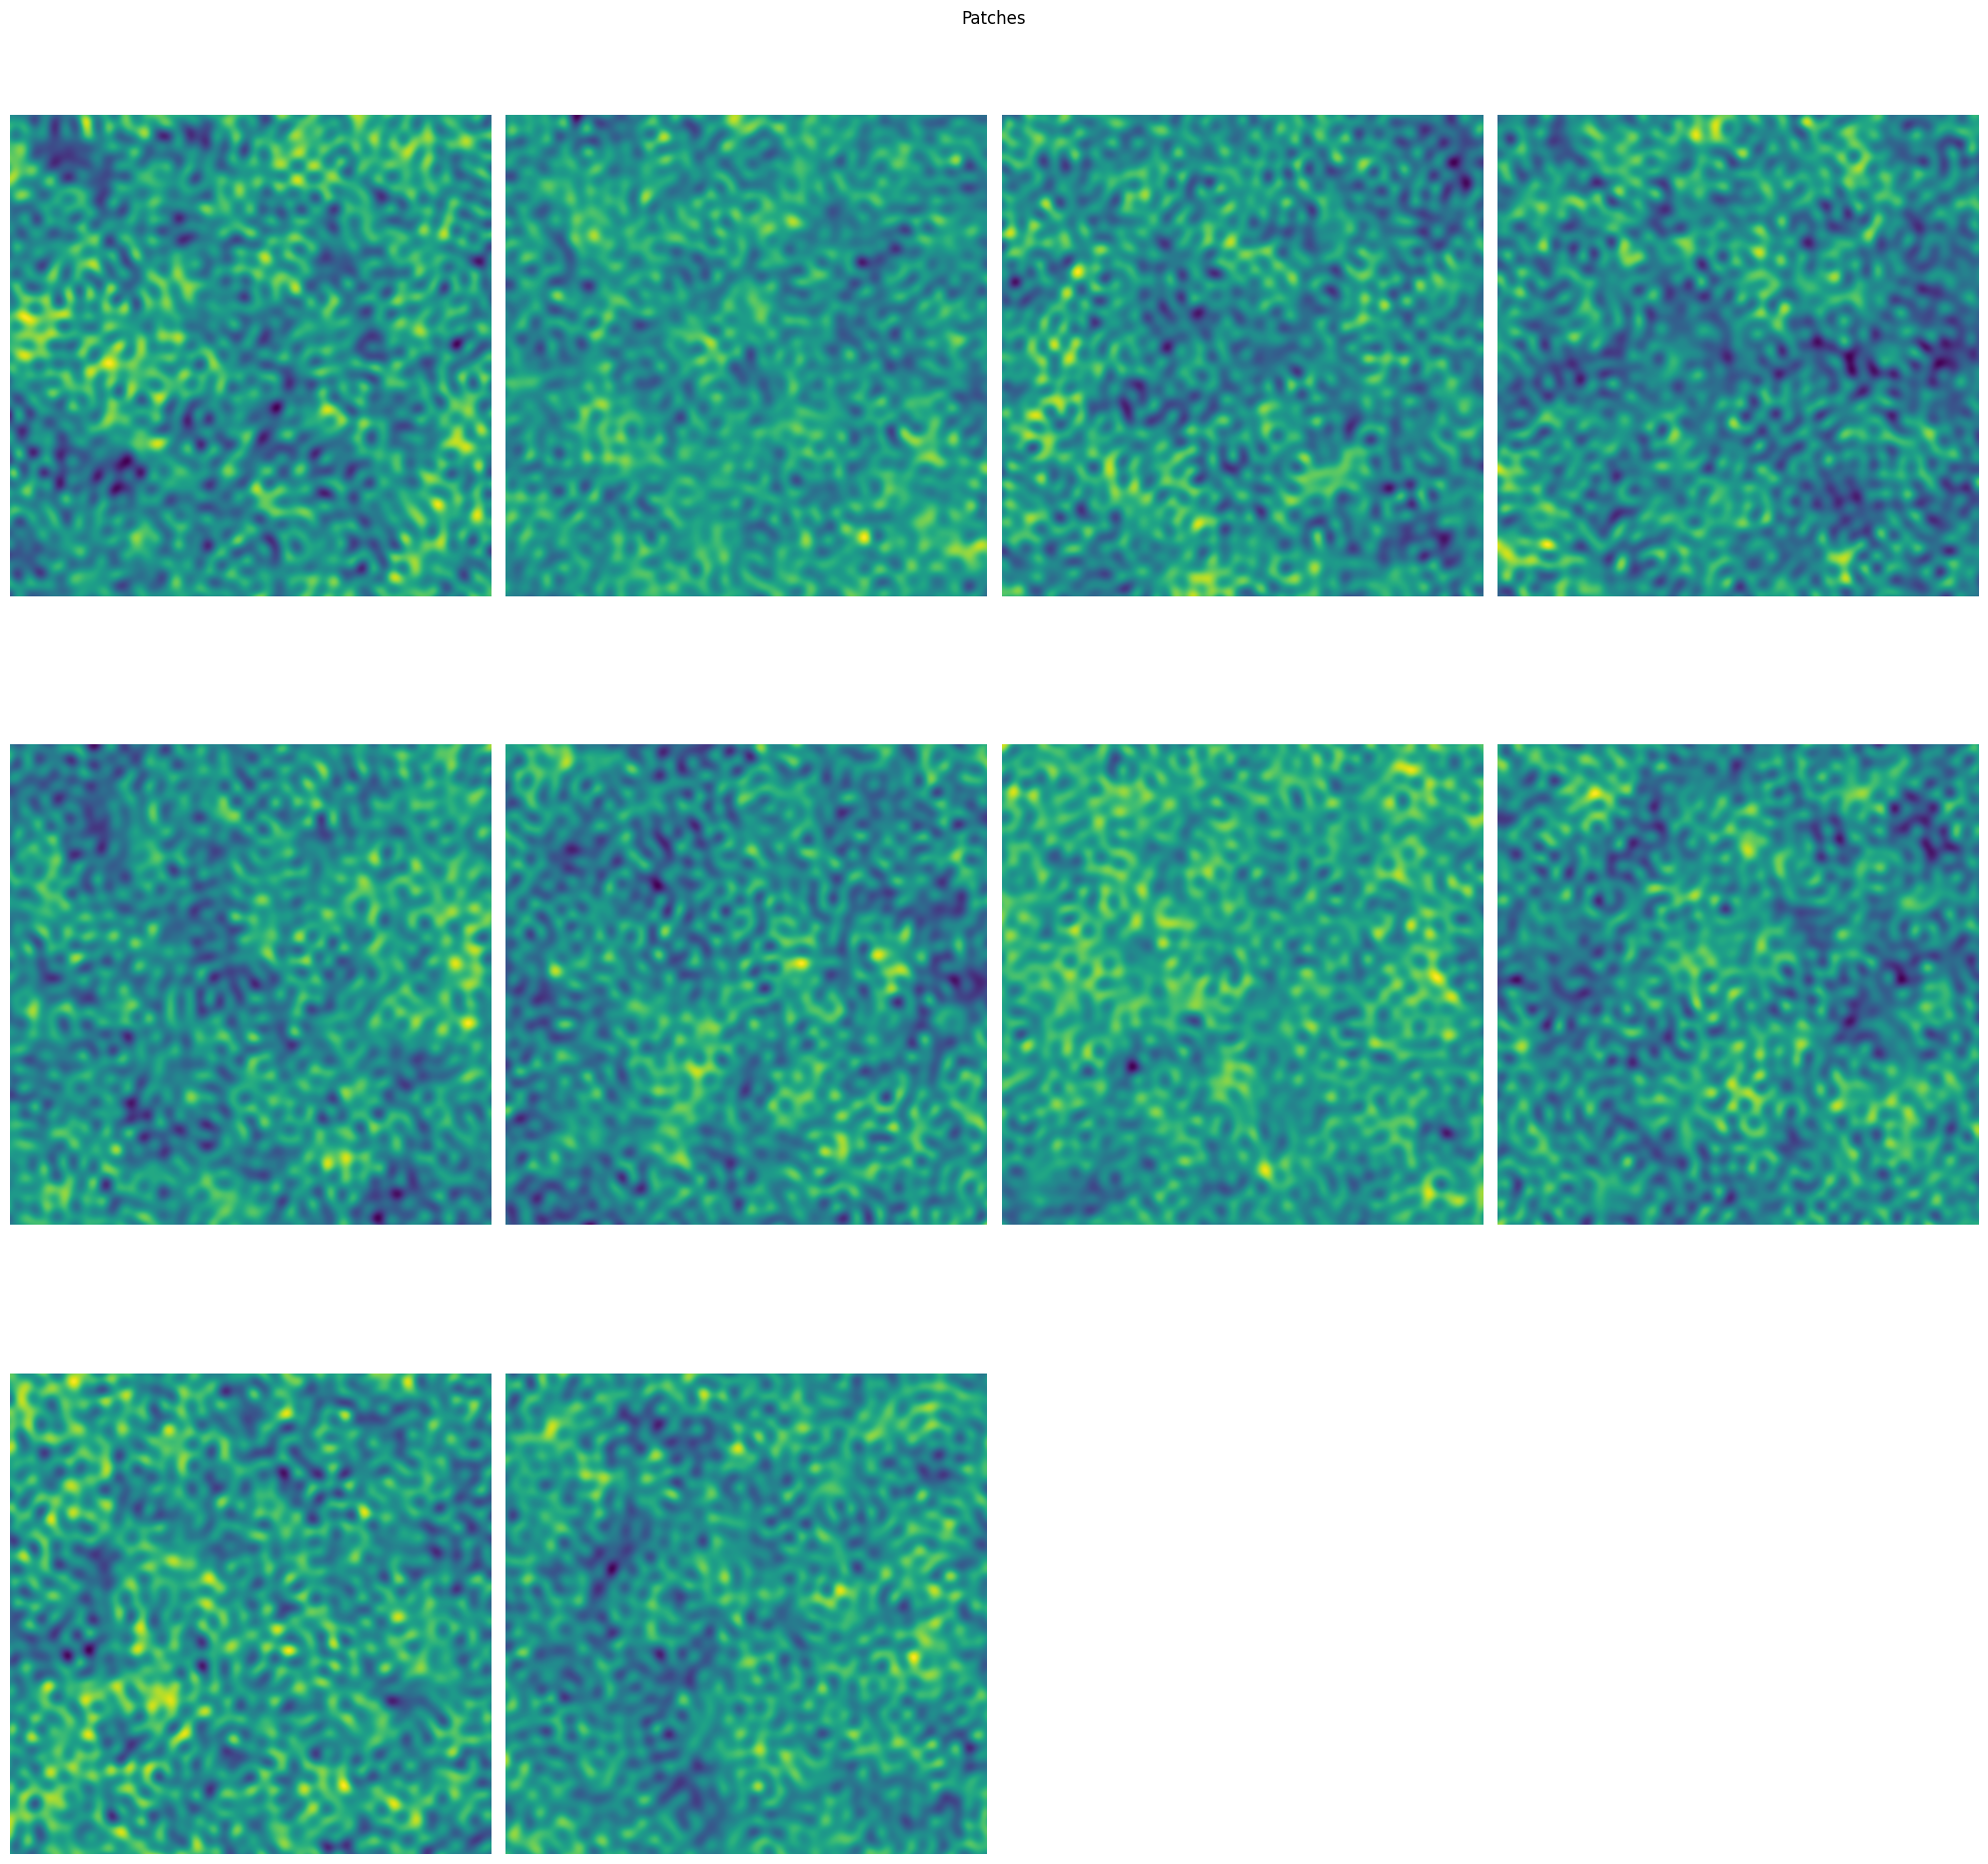

In [52]:
plot_patches(patches[0, 0], 10)

## Estimator

In [53]:
def alm_step_loader(idx):
    return s.data.compute_alm_sim(s.lensing)


theta_batch = int(np.floor(1.5 * s.lmax + 1)) // s.scpus
logger.info("Running KSW step with %s threads", s.scpus)
s.ksw.step_batch(alm_step_loader, range(100), theta_batch=theta_batch)

23-Apr-24 11:58:26 - __main__ - INFO - Running KSW step with 64 threads                             ]8;id=983473;file:///tmp/ipykernel_2679709/2433904915.py\2433904915.py]8;;\:]8;id=279339;file:///tmp/ipykernel_2679709/2433904915.py#7\7]8;;\

23-Apr-24 11:58:26 - KSW_joblib - INFO - processing 0                                             ]8;id=447045;file:///users/stevensonb/Research/MLPNG/ksw_joblib.py\ksw_joblib.py]8;;\:]8;id=642631;file:///users/stevensonb/Research/MLPNG/ksw_joblib.py#116\116]8;;\

23-Apr-24 11:58:43 - KSW_joblib - INFO - processing 1                                             ]8;id=402186;file:///users/stevensonb/Research/MLPNG/ksw_joblib.py\ksw_joblib.py]8;;\:]8;id=664682;file:///users/stevensonb/Research/MLPNG/ksw_joblib.py#116\116]8;;\

23-Apr-24 11:59:00 - KSW_joblib - INFO - processing 2                                             ]8;id=727573;file:///users/stevensonb/Research/MLPNG/ksw_joblib.py\ksw_joblib.py]8;;\:]8;id=365898;file:///users/stevensonb/Research/MLPNG/ksw_joblib.py#116\116]8;;\

23-Apr-24 11:59:17 - KSW_joblib - INFO - processing 3                                             ]8;id=693218;file:///users/stevensonb/Research/MLPNG/ksw_joblib.py\ksw_joblib.py]8;;\:]8;id=885095;file:///users/stevensonb/Research/MLPNG/ksw_joblib.py#116\116]8;;\

...

23-Apr-24 12:19:50 - KSW_joblib - INFO - processing 76                                            ]8;id=931126;file:///users/stevensonb/Research/MLPNG/ksw_joblib.py\ksw_joblib.py]8;;\:]8;id=411582;file:///users/stevensonb/Research/MLPNG/ksw_joblib.py#116\116]8;;\

23-Apr-24 12:20:06 - KSW_joblib - INFO - processing 77                                            ]8;id=183686;file:///users/stevensonb/Research/MLPNG/ksw_joblib.py\ksw_joblib.py]8;;\:]8;id=835147;file:///users/stevensonb/Research/MLPNG/ksw_joblib.py#116\116]8;;\

23-Apr-24 12:20:22 - KSW_joblib - INFO - processing 78                                            ]8;id=771632;file:///users/stevensonb/Research/MLPNG/ksw_joblib.py\ksw_joblib.py]8;;\:]8;id=754287;file:///users/stevensonb/Research/MLPNG/ksw_joblib.py#116\116]8;;\

23-Apr-24 12:20:39 - KSW_joblib - INFO - processing 79                                            ]8;id=357946;file:///users/stevensonb/Research/MLPNG/ksw_joblib.py\ksw_joblib.py]8;;\:]8;id=932057;file:///users/stevensonb/Research/MLPNG/ksw_joblib.py#116\116]8;;\

23-Apr-24 12:20:56 - KSW_joblib - INFO - processing 80                                            ]8;id=460953;file:///users/stevensonb/Research/MLPNG/ksw_joblib.py\ksw_joblib.py]8;;\:]8;id=734873;file:///users/stevensonb/Research/MLPNG/ksw_joblib.py#116\116]8;;\

In [ ]:
fisher = float(s.ksw.compute_fisher())
logger.info("Fisher: %s, standard deviation: %s", fisher, np.sqrt(1 / fisher))

In [ ]:
def alm_loader(i):
    logger.info("Loading alm %s, FNL %s", i, fnls[i, 0])
    return alms[i, 0]


idxs = range(alms.shape[0])
estimates = s.ksw.compute_estimate_batch(
    alm_loader, idxs, theta_batch=theta_batch, fisher=fisher
)